# Сторона бедра

Собирает `femur_img_labels.csv` из `metadata_train.csv`. Повторы одного снимка схлопываются по пикселям. Метка `femur_lay` и `femur_roi` берётся из колонки своей стороны: `rfem_*` для правого кадра и `lfem_*` для левого.


## Пути


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom

import dxa_utils as U

EXCEL_PATH = r"НД_для_обучения/разметка.xlsx"
TEST_DIR = r"Для теста/Для теста"

LABEL_COLUMNS = [
    "n",
    "study",
    "spine_lay",
    "spine_axis",
    "spine_obj",
    "rfem_lay",
    "rfem_roi",
    "lfem_lay",
    "lfem_roi",
    "total_spine",
    "total_rfem",
    "total_lfem",
    "comment",
    "c13",
    "c14",
    "c15",
    "c16",
    "c17",
    "c18",
]


## Уникальные снимки


In [2]:
df_meta = pd.read_csv("metadata_train.csv")
femur_files = df_meta.loc[
    df_meta["anatomical_region"] == U.FEMUR_REGION, ["file_path", "study_id"]
].copy()

rows = []
for _, row in femur_files.iterrows():
    arr = pydicom.dcmread(row["file_path"]).pixel_array
    rows.append(
        {
            "file_path": row["file_path"],
            "study_id": row["study_id"],
            "height": int(arr.shape[0]),
            "md5": U.pixel_hash(arr),
            "score_a": U.orientation_score_a(arr),
            "score_b": U.shaft_offset_b(arr),
        }
    )

df_files = pd.DataFrame(rows)
df_unique = df_files.groupby(["study_id", "md5"], as_index=False).agg(
    file_path=("file_path", "first"),
    height=("height", "first"),
    score_a=("score_a", "first"),
    score_b=("score_b", "first"),
    n_files=("file_path", "size"),
)
print(
    f"Femur files: {len(df_files)}; "
    f"unique pixel images: {len(df_unique)}; "
    f"studies: {df_unique.study_id.nunique()}"
)


Femur files: 331; unique pixel images: 151; studies: 78


## Метки своей стороны


In [3]:
side, source = U.resolve_femur_sides(df_unique)
df_unique["femur_side"] = side
df_unique["side_source"] = source

labels = pd.read_excel(EXCEL_PATH, header=None).iloc[2:].reset_index(drop=True)
labels.columns = LABEL_COLUMNS
labels["study"] = labels["study"].astype(str).str.strip()
for column in ["rfem_lay", "rfem_roi", "lfem_lay", "lfem_roi"]:
    labels[column] = pd.to_numeric(labels[column], errors="coerce")

img = df_unique.merge(
    labels[["study", "rfem_lay", "rfem_roi", "lfem_lay", "lfem_roi", "comment"]].rename(
        columns={"study": "study_id"}
    ),
    on="study_id",
    how="left",
)


def own_side_label(row, right_col, left_col):
    if row["femur_side"] == "R":
        return row[right_col]
    if row["femur_side"] == "L":
        return row[left_col]
    return np.nan


img["femur_lay"] = img.apply(lambda row: own_side_label(row, "rfem_lay", "lfem_lay"), axis=1)
img["femur_roi"] = img.apply(lambda row: own_side_label(row, "rfem_roi", "lfem_roi"), axis=1)
img["height_mm"] = img["height"] * U.PX_Y_MM

print("Side:", img["femur_side"].value_counts(dropna=False).to_dict())
print("Side source:", img["side_source"].value_counts(dropna=False).to_dict())
print(
    "femur_lay labeled:",
    int(img["femur_lay"].notna().sum()),
    "positive:",
    int(img["femur_lay"].sum()),
)
print(
    "femur_roi labeled:",
    int(img["femur_roi"].notna().sum()),
    "positive:",
    int(img["femur_roi"].sum()),
)


Side: {'L': 77, 'R': 72, 'unknown': 2}
Side source: {'pair': 144, 'single_AB': 5, 'none': 2}
femur_lay labeled: 148 positive: 34
femur_roi labeled: 148 positive: 7


## Проверка стороны

Сначала таблица одиночных исследований, у которых в Excel заполнена только одна сторона. Затем пары и согласие признаков A и B. Правых одиночных исследований в train нет: направление R подтверждается парами и открытым тестом ниже.


In [4]:
n_unique = img.groupby("study_id")["md5"].transform("nunique")
known_left = img[(n_unique == 1) & img["lfem_lay"].notna() & img["rfem_lay"].isna()]
known_right = img[(n_unique == 1) & img["rfem_lay"].notna() & img["lfem_lay"].isna()]
confusion = pd.DataFrame(
    {
        "pred_L": [
            (known_left["femur_side"] == "L").sum(),
            (known_right["femur_side"] == "L").sum(),
        ],
        "pred_R": [
            (known_left["femur_side"] == "R").sum(),
            (known_right["femur_side"] == "R").sum(),
        ],
        "unknown": [
            (known_left["femur_side"] == "unknown").sum(),
            (known_right["femur_side"] == "unknown").sum(),
        ],
    },
    index=[f"known L (n={len(known_left)})", f"known R (n={len(known_right)})"],
)
print(confusion)

pairs = img.groupby("study_id").filter(lambda group: len(group) == 2)
n_pairs = pairs["study_id"].nunique()
opposite = pairs.groupby("study_id")["score_a"].apply(
    lambda series: np.sign(series.iloc[0]) != np.sign(series.iloc[1])
).sum()
resolved = pairs.groupby("study_id")["side_source"].apply(
    lambda series: (series == "pair").all()
).sum()
print(f"pairs={n_pairs}; opposite A signs={opposite}; resolved pairs={resolved}")

a_side = np.where(img["score_a"] > 0, "R", "L")
b_side = np.where(img["score_b"] < 0, "R", "L")
print(f"A/B agreement: {np.mean(a_side == b_side):.1%}")
print("Unknown images:")
print(
    img.loc[
        img["femur_side"] == "unknown",
        ["study_id", "score_a", "score_b", "side_source"],
    ].to_string(index=False)
)


               pred_L  pred_R  unknown
known L (n=5)       5       0        0
known R (n=0)       0       0        0
pairs=73; opposite A signs=73; resolved pairs=72
A/B agreement: 92.7%
Unknown images:
                                    study_id   score_a   score_b side_source
2.25.128990540359421489042453547244535073735  0.150750  0.106272        none
2.25.128990540359421489042453547244535073735 -0.184116 -0.035406        none


## Контактные листы

Смотреть до обучения `femur_lay`. Если хотя бы один canonical-кадр развёрнут наоборот, правило стороны исправляется до обучения.


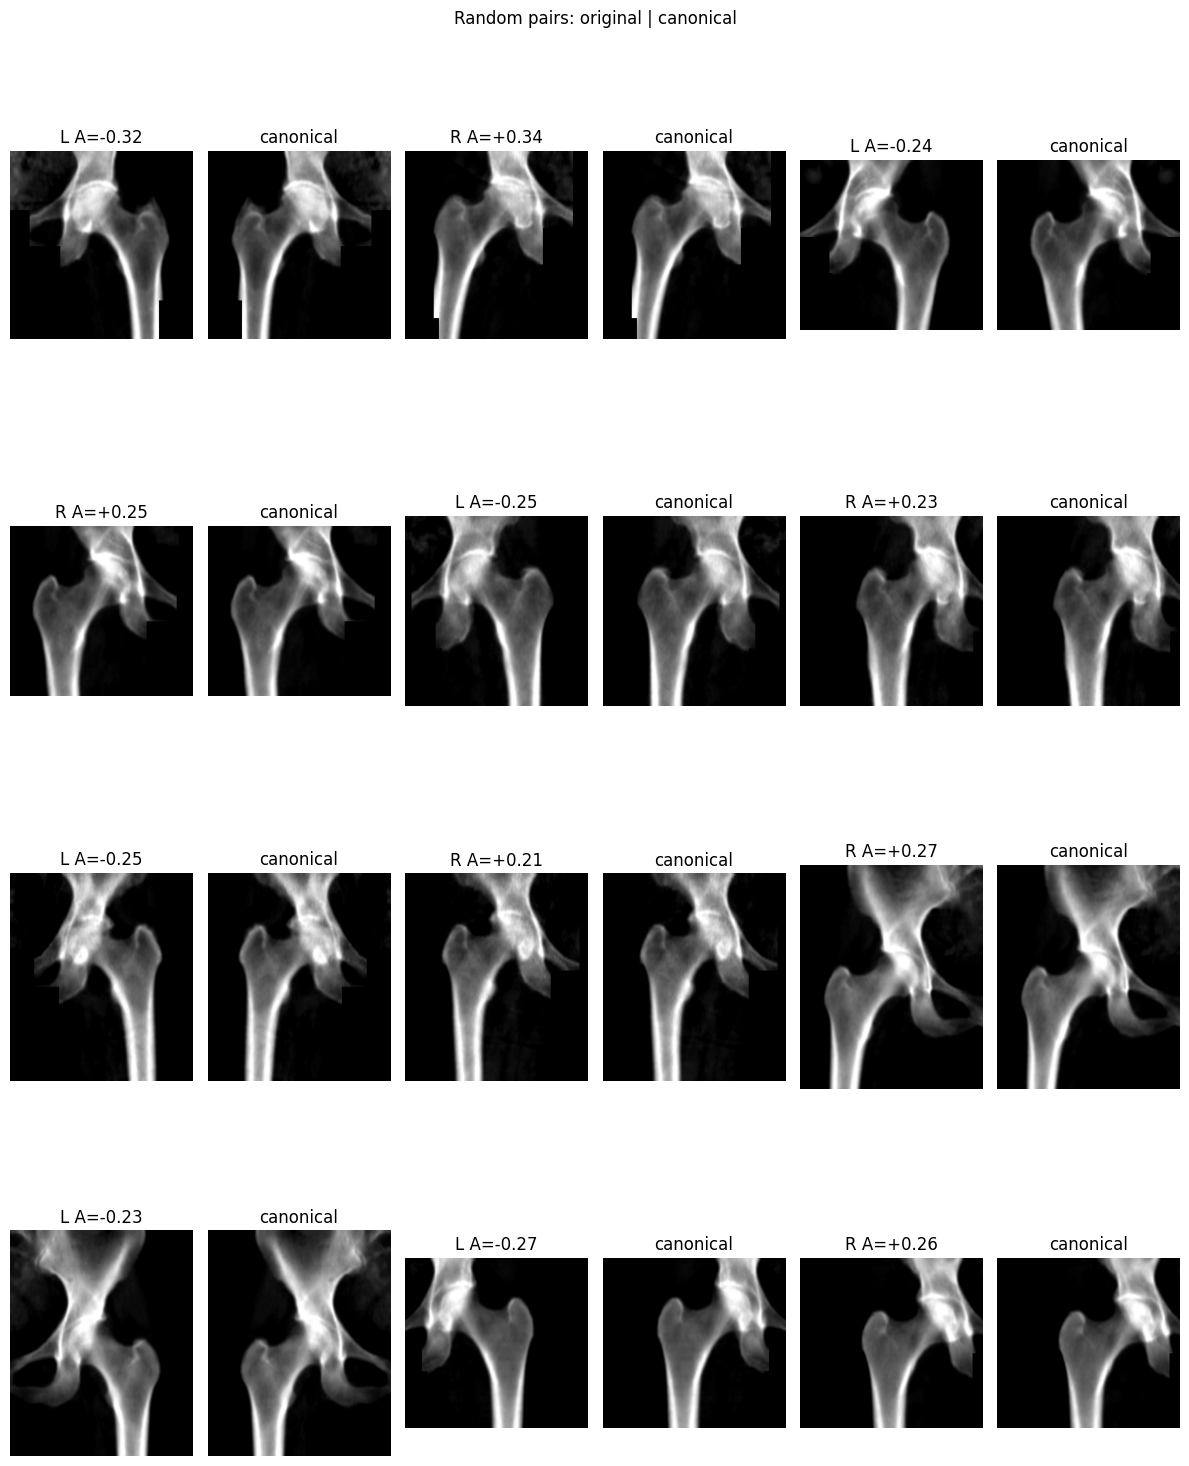

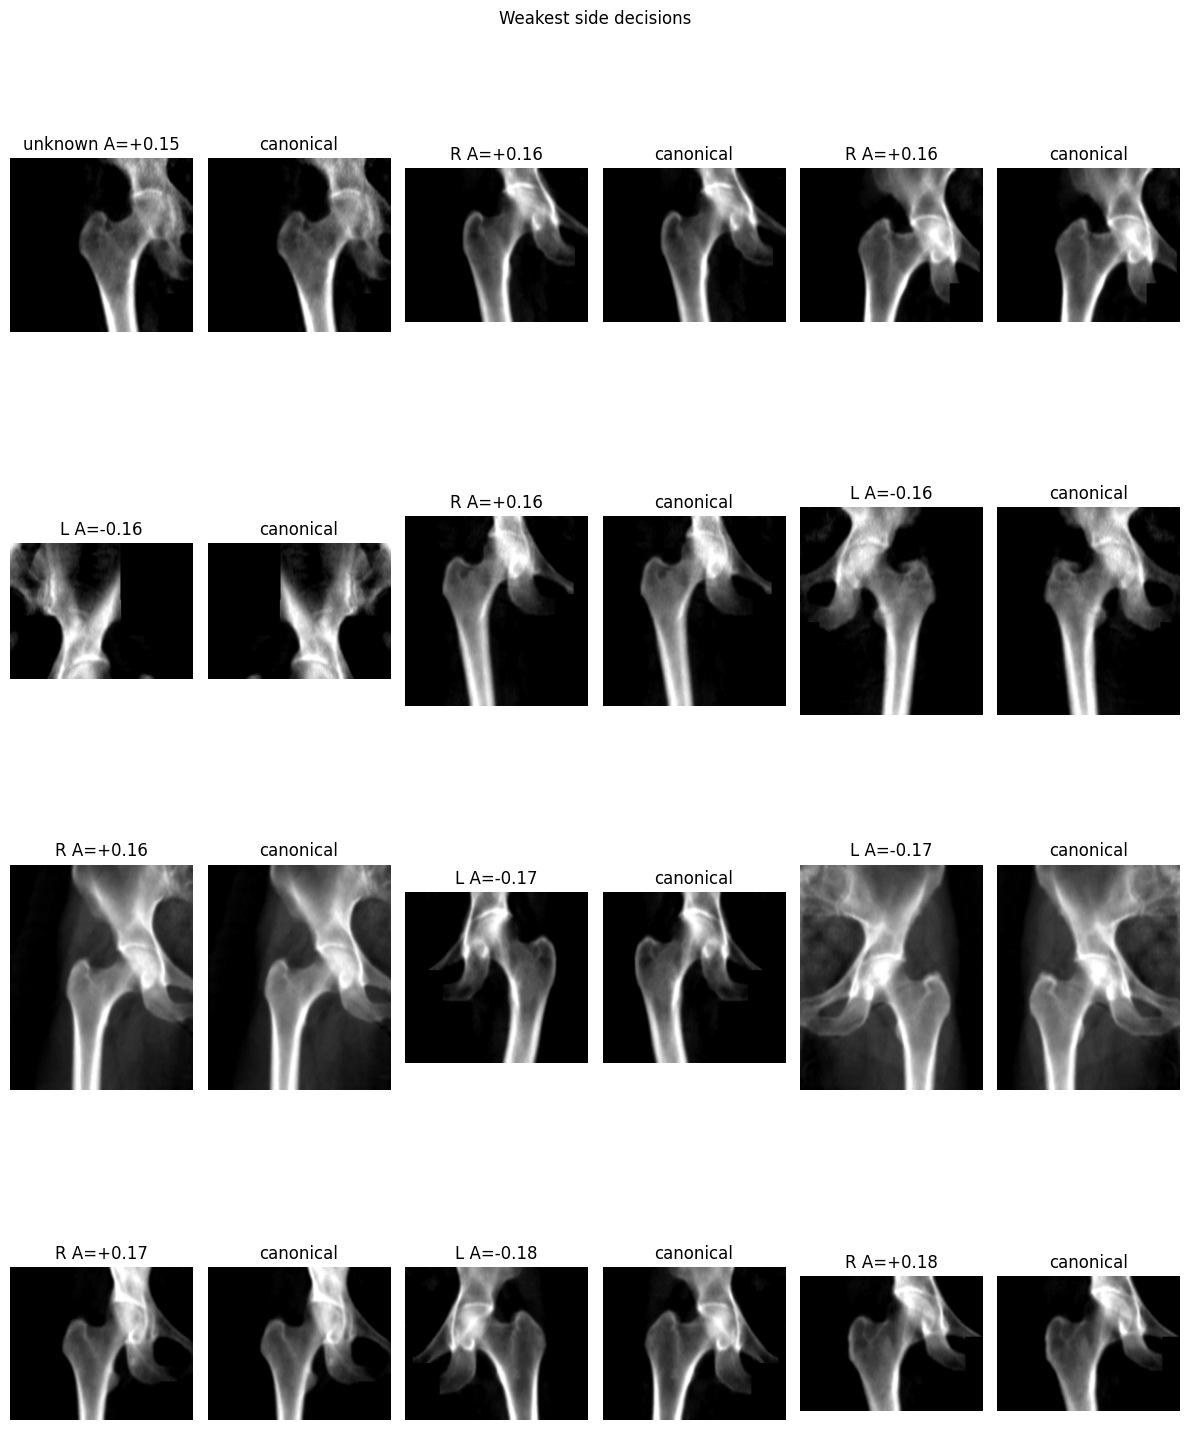

In [5]:
def display_norm(arr):
    arr = arr.astype(np.float32)
    lo, hi = np.percentile(arr, [1, 99.5])
    return np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)


def show_orig_vs_canon(rows_df, title, fname, per_row=3):
    n_rows = max(1, (len(rows_df) + per_row - 1) // per_row)
    fig, axes = plt.subplots(n_rows, per_row * 2, figsize=(12, 4 * n_rows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for i, (_, row) in enumerate(rows_df.iterrows()):
        arr = pydicom.dcmread(row["file_path"]).pixel_array
        canon = U.canonicalize_femur(arr, row["femur_side"])
        row_i, col_i = divmod(i, per_row)
        axes[row_i, 2 * col_i].imshow(display_norm(arr), cmap="gray")
        axes[row_i, 2 * col_i].set_title(f"{row['femur_side']} A={row['score_a']:+.2f}")
        axes[row_i, 2 * col_i + 1].imshow(display_norm(canon), cmap="gray")
        axes[row_i, 2 * col_i + 1].set_title("canonical")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(fname, dpi=110)
    plt.show()
    plt.close(fig)


rng = np.random.RandomState(0)
pair_studies = pairs["study_id"].unique()
if len(pair_studies):
    sample_studies = rng.choice(pair_studies, size=min(6, len(pair_studies)), replace=False)
    show_orig_vs_canon(
        img[img.study_id.isin(sample_studies)],
        "Random pairs: original | canonical",
        "side_check_random.png",
    )

weak = img.assign(abs_a=img.score_a.abs()).sort_values("abs_a").head(12)
show_orig_vs_canon(weak, "Weakest side decisions", "side_check_weak.png")


## Сохранение


In [6]:
columns = [
    "file_path",
    "study_id",
    "md5",
    "n_files",
    "height",
    "height_mm",
    "score_a",
    "score_b",
    "femur_side",
    "side_source",
    "femur_lay",
    "femur_roi",
    "comment",
]
img[columns].to_csv("femur_img_labels.csv", index=False)
print("saved -> femur_img_labels.csv")


saved -> femur_img_labels.csv


## Открытый тест

Суффикс имени `ППОБ` / `ЛПОБ` используется только здесь, чтобы сверить детектор. В обучение он не входит.


In [7]:
if os.path.isdir(TEST_DIR):
    rows_test = []
    for root, _, fnames in os.walk(TEST_DIR):
        for fname in sorted(fnames):
            if not fname.lower().endswith(".dcm"):
                continue
            path = os.path.join(root, fname)
            arr = pydicom.dcmread(path).pixel_array
            if arr.shape[1] != U.FEMUR_WIDTH:
                continue
            info = U.detect_femur_side(arr)
            if "ППОБ" in fname:
                expected = "R"
            elif "ЛПОБ" in fname:
                expected = "L"
            else:
                expected = "?"
            rows_test.append(
                {
                    "file": fname,
                    "expected": expected,
                    "predicted": info["side"],
                    "confident": info["confident"],
                }
            )
    test_side = pd.DataFrame(rows_test)
    print("Open-test side check:")
    print(test_side.to_string(index=False))


Open-test side check:
             file expected predicted  confident
CR000000_ППОБ.dcm        R         R       True
CR000001_ЛПОБ.dcm        L         L       True
